### 08. PyTorch Model Deployment

## imports

In [2]:
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms
from torchinfo import summary
from going_modular import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves

c:\Users\yokes\anaconda3\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#Device setup
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### 1. Getting data

In [4]:
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data\pizza_steak_sushi_20_percent directory exists, skipping download.


WindowsPath('data/pizza_steak_sushi_20_percent')

In [5]:
# Setup directory paths to train and test images
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

## 2. Creating an EffNetB2 feature extractor

In [6]:
# Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
# Get EffNetB2 transforms
effnetb2_transform = effnetb2_weights.transforms()
# Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)
# Freeze the base layers in the model (this will freeze all layers to begin with)
for params in effnetb2.parameters():
    params.requires_grad = False

In [7]:
# Check out EffNetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [8]:
# Update the classiffier
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3,inplace=True),
    nn.Linear(in_features=1408,
              out_features=3)
)

In [9]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

### 2.1 Creating a function to make an EffNetB2 feature extractor

In [10]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [11]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)

In [12]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=3, bias=True)
)

In [13]:
from torchinfo import summary

# Print EffNetB2 model summary (uncomment for full output) 
summary(effnetb2, 
         input_size=(1, 3, 224, 224),
         col_names=["input_size", "output_size", "num_params", "trainable"],
         col_width=20,
         row_settings=["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 2.2 Creating DataLoaders for EffNetB2

In [14]:
# Setup DataLoaders
from going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

### 2.3 Training EffNetB2 feature extractor

In [15]:
from going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set seeds for reproducibility and train the model
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=10,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9797 | train_acc: 0.5687 | test_loss: 0.7365 | test_acc: 0.9347


 10%|█         | 1/10 [00:13<02:05, 13.90s/it]

Epoch: 2 | train_loss: 0.7102 | train_acc: 0.8562 | test_loss: 0.5842 | test_acc: 0.9472


 20%|██        | 2/10 [00:23<01:31, 11.42s/it]

...

 80%|████████  | 8/10 [01:22<00:19,  9.90s/it]

Epoch: 9 | train_loss: 0.3734 | train_acc: 0.8979 | test_loss: 0.3100 | test_acc: 0.9256


 90%|█████████ | 9/10 [01:32<00:09,  9.93s/it]

Epoch: 10 | train_loss: 0.3648 | train_acc: 0.8646 | test_loss: 0.2782 | test_acc: 0.9625


100%|██████████| 10/10 [01:43<00:00, 10.32s/it]


### 2.4 Inspecting EffNetB2 loss curves

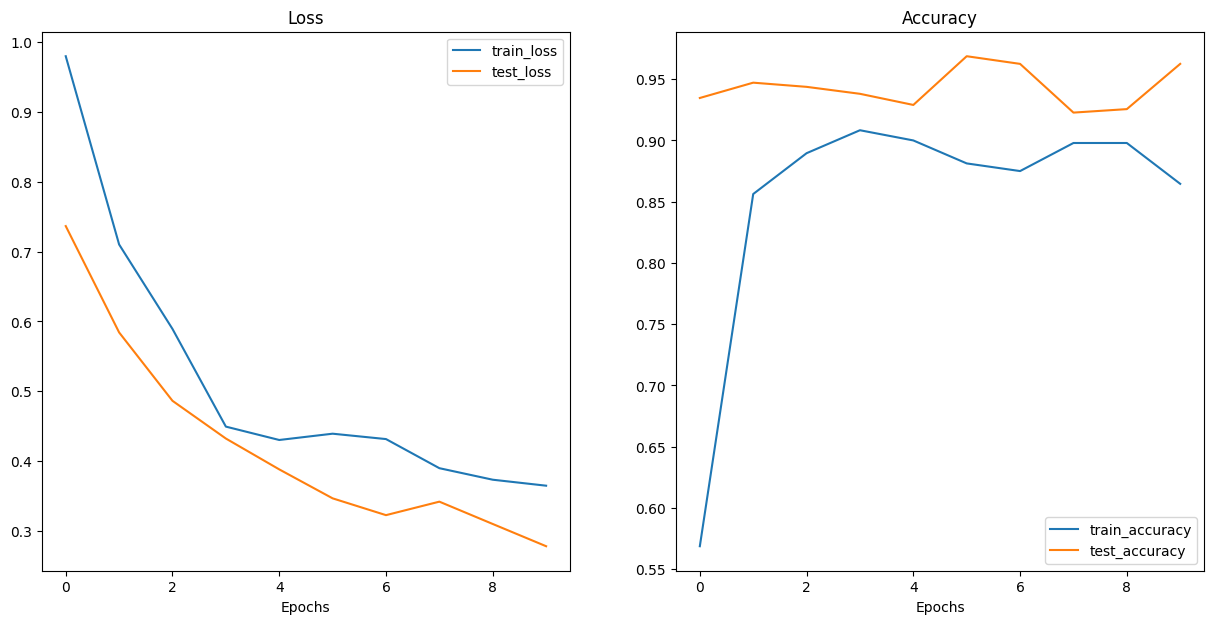

In [16]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

### 2.5 Saving EffNetB2 feature extractor

In [18]:
from going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="08_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models\08_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


### 2.6 Checking the size of EffNetB2 feature extractor

In [19]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


### 2.7 Collecting EffNetB2 feature extractor stats

In [20]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params


7705221

In [21]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.27815687358379365,
 'test_acc': 0.9625,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

## 3. Making predictions with our trained model and timing them

### 3.1 Creating the function to make prediction across the test dataset

In [25]:
import pathlib
import torch

from PIL import Image
from timeit import default_timer as timer 
from tqdm.auto import tqdm
from typing import List,Dict

# Create the function to the return a list of dictionaries with sample, truth label, prediction, prediction probability and prediction time
def pred_and_store(paths: List[pathlib.Path],
                   model: torch.nn.Module,
                   transform: torchvision.transforms,
                   class_names: List[str],
                   device: str = "cuda" if torch.cuda.is_available() else "cpu") -> List[Dict]:
    
    #create the empty list to store the prediction dictionaries
    pred_list =[]

    # Loop through the path
    for path in tqdm(paths):

        # create the empty dictionary to store prediction information for each sample
        pred_dict = {}

        # Get the sample path and ground truth class name
        pred_dict["image_path"] = path
        class_name = path.parent.stem
        pred_dict["class_name"] = class_name

        #Start the prediction timer
        start_time = timer()

        # open the image using `PIL.Image.open(path)`
        img = Image.open(path)

        #Transform the image to be usable with a given model
        transformed_img = transform(img).unsqueeze(0).to(device)

        #eval mode
        model = model.to(device)
        model.eval()

        #Turn on the inference mode and predict the image class and probs
        with torch.inference_mode():
            pred_logit = model(transformed_img)
            pred_prob = torch.softmax(pred_logit,dim =1)
            pred_label = torch.argmax(pred_prob,dim=1)
            pred_class = class_names[pred_label.cpu()]

            # Add the pred prob , pred class in dict
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(),4)
            pred_dict["pred_class"] = pred_class

            #timer stop
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time,4)

        pred_dict["correct"] = class_name == pred_class

        pred_list.append(pred_dict)

    return pred_list
